# Importy


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, GridSearchCV
import tensorflow as tf
from tensorflow import keras

# Wykresy danych


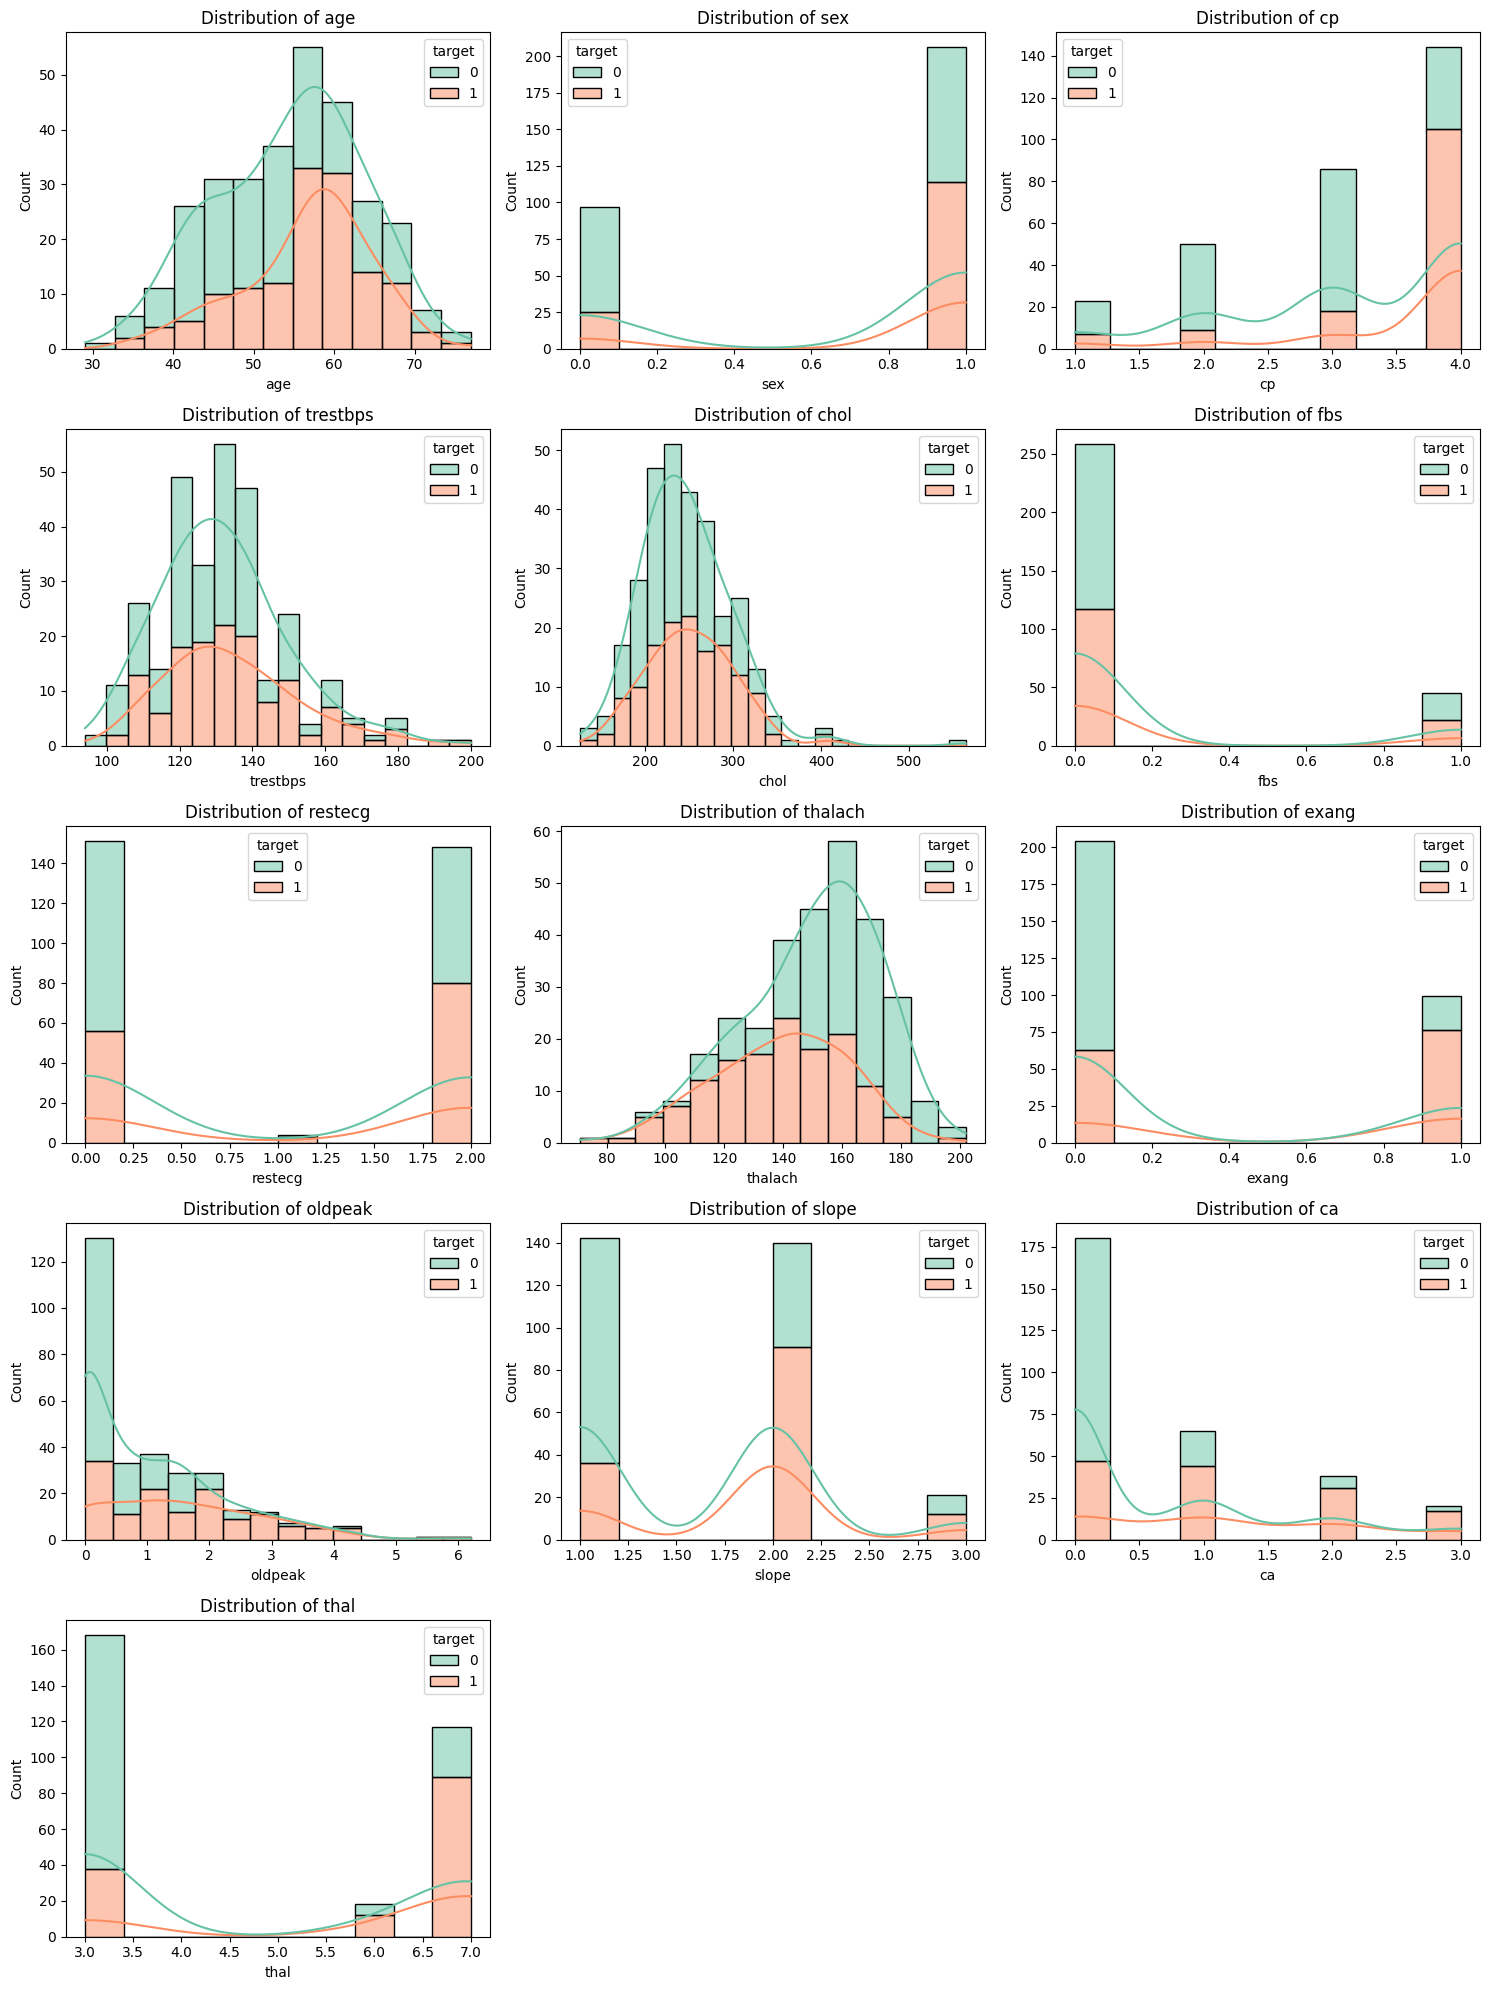

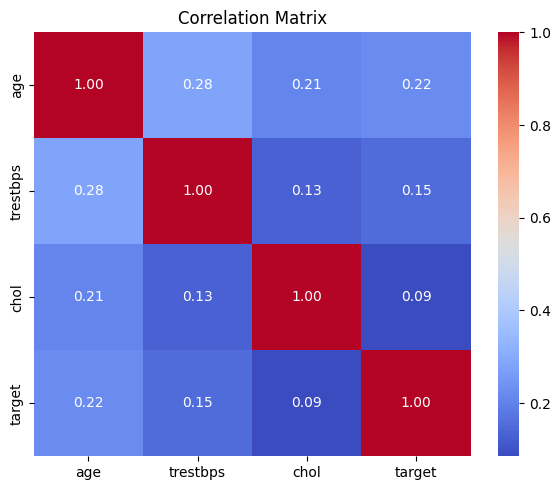

In [18]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=columns, na_values='?')
df.fillna(df.median(), inplace=True)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

plt.figure(figsize=(15, 20))
features = [col for col in columns if col != 'target']
for i, col in enumerate(features, 1):
  plt.subplot(5, 3, i)
  sns.histplot(data=df, x=col, hue='target', kde=True, multiple="stack", palette="Set2")
  plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show() #wyświetlanie
plt.close()

plt.figure(figsize=(6, 5))
sns.heatmap(df[['age', 'trestbps', 'chol', 'target']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
plt.close()

# Preprocessing danych


In [19]:

X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_df = pd.DataFrame(X_train_scaled, columns=features)
train_df['target'] = y_train.values

test_df = pd.DataFrame(X_test_scaled, columns=features)
test_df['target'] = y_test.values


In [20]:
#Podgląd

test_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.495681,0.68313,0.870169,0.400391,0.401254,-0.411196,1.022996,1.415100,-0.696177,-0.891627,-0.958585,-0.689715,-0.878070,0
1,1.275333,0.68313,0.870169,1.651379,-0.414104,-0.411196,1.022996,-0.528404,-0.696177,1.160812,-0.958585,-0.689715,0.665462,0
2,-0.395349,-1.46385,-0.157055,-0.054513,0.116827,-0.411196,1.022996,-0.042528,-0.696177,-0.445445,-0.958585,-0.689715,-0.878070,0
3,-2.288787,0.68313,-2.211502,-0.736870,-1.286348,-0.411196,1.022996,1.061736,-0.696177,-0.891627,-0.958585,-0.689715,-0.878070,0
4,-0.061212,0.68313,-0.157055,1.082748,-0.338257,-0.411196,1.022996,0.664201,-0.696177,0.536156,-0.958585,-0.689715,1.179973,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,0.384303,0.68313,0.870169,-0.964323,1.292459,-0.411196,0.020708,-0.440063,-0.696177,3.034778,2.308704,2.716634,0.665462,1
57,0.718439,0.68313,-2.211502,0.172939,-0.300333,-0.411196,-0.981579,-0.219210,-0.696177,1.428521,0.675060,1.581184,-0.878070,1
58,0.941197,-1.46385,-0.157055,0.229802,0.040979,-0.411196,1.022996,0.973394,-0.696177,-0.891627,-0.958585,-0.689715,-0.878070,0
59,0.050166,-1.46385,-1.184278,0.059213,1.747543,-0.411196,-0.981579,0.708371,-0.696177,0.179210,-0.958585,-0.689715,-0.878070,0


# Modele (MLPClassifier, RandomForestClassifier, SVC, KNeighborsClassifier)

In [21]:
models = {
        'RandomForest (Base)': RandomForestClassifier(random_state=42),
        'SVC (Base)': SVC(random_state=42),
        'KNN (Base)': KNeighborsClassifier(),
        'MLP Sklearn (Base)': MLPClassifier(random_state=42, max_iter=1000)
    }

models1 = models.copy()

print("Wyniki trenowania bazowych modeli:")
for name, model in models.items():
  model.fit(X_train, y_train)
  preds = model.predict(X_test)
  acc = accuracy_score(y_test, preds)
  print(f"{name} - accuracy: {acc*100:.2f}%")


print("Wyniki trenowania bazowych modeli (dane scaled):")
for name, model in models1.items():
  model.fit(X_train_scaled, y_train)
  preds = model.predict(X_test_scaled)
  acc = accuracy_score(y_test, preds)
  print(f"{name} - accuracy: {acc*100:.2f}%") #poprawa dla MLP Sklearn

Wyniki trenowania bazowych modeli:
RandomForest (Base) - accuracy: 88.52%
SVC (Base) - accuracy: 68.85%
KNN (Base) - accuracy: 70.49%
MLP Sklearn (Base) - accuracy: 86.89%
Wyniki trenowania bazowych modeli (dane scaled):
RandomForest (Base) - accuracy: 88.52%
SVC (Base) - accuracy: 85.25%
KNN (Base) - accuracy: 88.52%
MLP Sklearn (Base) - accuracy: 83.61%


# MLP (tensorflow)

In [22]:
print('UWAGA - zmień środowisko wykonawcze na typ GPU T4!!!!!!')

device_name = tf.test.gpu_device_name()

print(device_name)  #/device:GPU:0


y_train = (y_train > 0).astype(int) #musimy, bo operujemy binarnie
y_test = (y_test > 0).astype(int)

with tf.device(device_name):
  modeltf = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(len(features),)), #pierwsza warstwa ukryta Dense (64 neurony)
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid') # binarne wyjście
  ])

  modeltf.compile(
    optimizer='adam',
    loss='binary_crossentropy', #klasyfikacja binarna
    metrics=['accuracy'])

  modeltf.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2) #0.5389 = accuracy --> czyli w sumie taka sama jak na początku, jak zaobserwujemy pojedyczne epoki, to będzie widać, że robiło się lepiej --> gorzej --L lepiej --> gorzej
  loss, acc = modeltf.evaluate(X_test_scaled, y_test, verbose=0)
  print(f"Test accuracy: {acc*100:.4f}%")

#Test accuracy: 83.6066%

UWAGA - zmień środowisko wykonawcze na typ GPU T4!!!!!!
/device:GPU:0
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - accuracy: 0.4922 - loss: 0.6926 - val_accuracy: 0.6531 - val_loss: 0.6468
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7461 - loss: 0.6058 - val_accuracy: 0.7755 - val_loss: 0.5965
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8290 - loss: 0.5463 - val_accuracy: 0.8163 - val_loss: 0.5600
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8446 - loss: 0.5014 - val_accuracy: 0.8163 - val_loss: 0.5338
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8653 - loss: 0.4634 - val_accuracy: 0.8163 - val_loss: 0.5102
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8601 - loss: 0.4315 - val_accuracy: 0.8163 - val_loss: 0.4963
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8653 - loss: 0.4067 - val_accuracy: 0.7959 - val_loss: 0.4928
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8808 - loss: 0.3858 - val_accuracy: 0.7959 - val_loss: 0.4992
Epoch 9/50

## Optymalizacja warstw MLP (Multilayer Perceptron)

In [23]:
architectures=[[32,32], [64], [128, 64], [256, 128, 64]]
activations = ['relu', 'sigmoid', 'tanh']
optimizers = ['adam', 'sgd']

res = []

with tf.device(device_name):
  for arch in architectures:
    for act in activations:
      for opt in optimizers:
        modeltf = keras.Sequential()
        for units in arch:
          modeltf.add(keras.layers.Dense(units, activation=act))
        modeltf.add(keras.layers.Dense(1, activation='sigmoid')) #tym kończymy
        modeltf.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
        modeltf.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0) #verbose=0 --> brak logów epok, bo jest ich za dużo
        loss,acc = modeltf.evaluate(X_test_scaled, y_test, verbose=0)
        res.append({'architecture': str(arch), 'activation': act, 'optimizer': opt, 'test_acc': round(acc, 4)})


best = max(res, key=lambda x: x['test_acc'])
print("Best MLP:", best)

#Best MLP: {'architecture': '[32, 32]', 'activation': 'relu', 'optimizer': 'sgd', 'test_acc': 0.9016}

Best MLP: {'architecture': '[32, 32]', 'activation': 'relu', 'optimizer': 'sgd', 'test_acc': 0.9016}


## Optymalizacja liczby drzew RandomForest

In [24]:
estimators = [5,8,10, 20,30,50, 100, 200]

tree_res = []

for est in estimators:
    rf = RandomForestClassifier(n_estimators=est, random_state=27)
    scores = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring='accuracy')
    tree_res.append({'n_estimators': est, 'cv_mean': round(scores.mean(), 4), 'cv_std':  round(scores.std(),  4)})

tree_res = pd.DataFrame(tree_res)
tree_res

,n_estimators,cv_mean,cv_std
0,2,0.7025,0.0429
1,3,0.7522,0.0602
2,4,0.7517,0.0566
3,5,0.7642,0.0352
4,6,0.7768,0.0518
5,7,0.7684,0.0526
6,8,0.7932,0.0793
7,9,0.7848,0.0634
8,10,0.7973,0.0682
9,20,0.8014,0.0582


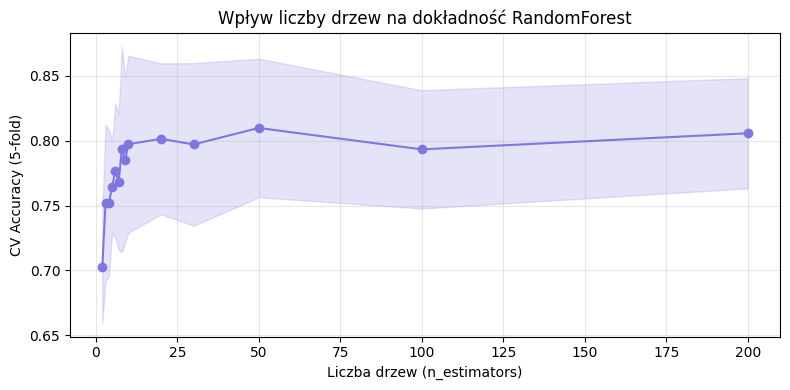

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tree_res['n_estimators'], tree_res['cv_mean'], marker='o', color='#7F77DD')
ax.fill_between(tree_res['n_estimators'],
                tree_res['cv_mean'] - tree_res['cv_std'],
                tree_res['cv_mean'] + tree_res['cv_std'],
                alpha=0.2, color='#7F77DD')
ax.set_xlabel('Liczba drzew (n_estimators)')
ax.set_ylabel('CV Accuracy (5-fold)')
ax.set_title('Wpływ liczby drzew na dokładność RandomForest')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show() #najwyższy dla est=200

# GridSearchCV

In [26]:
gs_results = {}

#SVC
gs_svc = GridSearchCV(SVC(),{'C': [0.1,1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']}, cv=5, scoring='accuracy',n_jobs=-1)
gs_svc.fit(X_train, y_train)
gs_results['SVC'] = gs_svc

#KNN
gs_knn = GridSearchCV(KNeighborsClassifier(),{'n_neighbors': [3, 5, 7, 9, 11], 'metric': ['euclidean', 'manhattan']},cv=5, scoring='accuracy',n_jobs=-1)
gs_knn.fit(X_train, y_train)
gs_results['KNN'] = gs_knn

#RandomForest
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=27),{'n_estimators': [2,6,10,50,100, 200], 'max_depth': [None, 5,10],'criterion': ['gini','entropy']},cv=5, scoring='accuracy',n_jobs=-1)
gs_rf.fit(X_train, y_train)
gs_results['RandomForest'] = gs_rf

#MLP sklearn
gs_mlp = GridSearchCV(MLPClassifier(max_iter=500, random_state=27),{'hidden_layer_sizes': [(50,), (100,), (100, 50)],'activation': ['relu', 'tanh'], 'alpha': [0.0001,0.001]},cv=5, scoring='accuracy',n_jobs=-1)
gs_mlp.fit(X_train, y_train)
gs_results['MLP_sklearn'] = gs_mlp

In [27]:

# Dla danych po StandradScaler


#SVC
gs_svc1 = GridSearchCV(SVC(),{'C': [0.1,1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']}, cv=5, scoring='accuracy',n_jobs=-1)
gs_svc1.fit(X_train_scaled, y_train)
gs_results['SVC_scaled'] = gs_svc1

#KNN
gs_knn1 = GridSearchCV(KNeighborsClassifier(),{'n_neighbors': [3, 5, 7, 9, 11], 'metric': ['euclidean', 'manhattan']},cv=5, scoring='accuracy',n_jobs=-1)
gs_knn1.fit(X_train_scaled, y_train)
gs_results['KNN_scaled'] = gs_knn1

#RandomForest
gs_rf1 = GridSearchCV(
    RandomForestClassifier(random_state=27),{'n_estimators': [2,6,10,50,100, 200], 'max_depth': [None, 5,10],'criterion': ['gini', 'entropy']},cv=5, scoring='accuracy',n_jobs=-1)
gs_rf1.fit(X_train_scaled, y_train)
gs_results['RandomForest_scaled'] = gs_rf1

#MLP sklearn
gs_mlp1 = GridSearchCV(MLPClassifier(max_iter=500, random_state=27),{'hidden_layer_sizes': [(50,), (100,), (100, 50)],'activation': ['relu', 'tanh'], 'alpha': [0.0001,0.001]},cv=5, scoring='accuracy',n_jobs=-1)
gs_mlp1.fit(X_train_scaled, y_train)
gs_results['MLP_sklearn_scaled'] = gs_mlp1

summary = []
for name, gs in gs_results.items():
    test_acc = gs.best_estimator_.score(X_test_scaled, y_test)
    summary.append({'Model': name,'Najlepsze parametry': gs.best_params_, 'CV accuracy': round(gs.best_score_, 4),'Test accuracy': round(test_acc, 4)})
    print(f"\n{name}")
    print(f"Params:{gs.best_params_}")
    print(f"CV accuracy:{gs.best_score_:.4f}")
    print(f"Test accuracy:{test_acc:.4f}")


SVC
Params:{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
CV accuracy:0.8304
Test accuracy:0.5902

KNN
Params:{'metric': 'manhattan', 'n_neighbors': 7}
CV accuracy:0.7273
Test accuracy:0.5410

RandomForest
Params:{'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 100}
CV accuracy:0.8180
Test accuracy:0.5902

MLP_sklearn
Params:{'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100,)}
CV accuracy:0.8139
Test accuracy:0.8689

SVC_scaled
Params:{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
CV accuracy:0.8304
Test accuracy:0.8852

KNN_scaled
Params:{'metric': 'euclidean', 'n_neighbors': 5}
CV accuracy:0.8430
Test accuracy:0.8852

RandomForest_scaled
Params:{'criterion': 'gini', 'max_depth': 5, 'n_estimators': 50}
CV accuracy:0.8179
Test accuracy:0.9016

MLP_sklearn_scaled
Params:{'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50,)}
CV accuracy:0.8139
Test accuracy:0.8361


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


# Feature Importance dla RandomForest (po GridSearchCV)

/tmp/ipykernel_503/2537500719.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='Ważność', y='Cecha', palette='muted', ax=ax, legend=False)


   Cecha  Ważność
    thal 0.131961
 thalach 0.117490
      ca 0.100936
     age 0.098369
      cp 0.097851
    chol 0.094358
 oldpeak 0.090579
trestbps 0.088755
   exang 0.061471
   slope 0.043112
     sex 0.037264
 restecg 0.024199
     fbs 0.013655


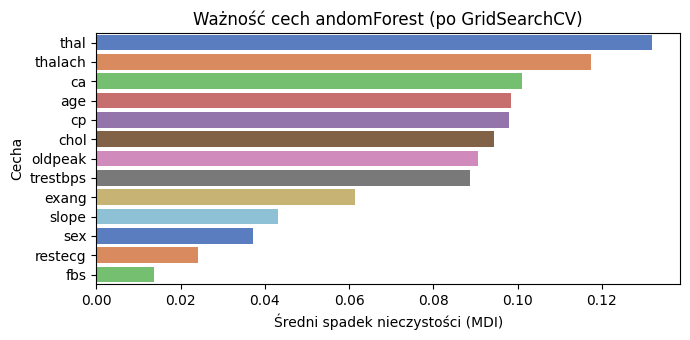

In [28]:
best_rf = gs_rf.best_estimator_
feature_names = X.columns.tolist()

fi_df = pd.DataFrame({
    'Cecha':     feature_names,
    'Ważność':   best_rf.feature_importances_
}).sort_values('Ważność', ascending=False)

print(fi_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(data=fi_df, x='Ważność', y='Cecha', palette='muted', ax=ax, legend=False)
ax.set_title('Ważność cech andomForest (po GridSearchCV)')
ax.set_xlabel('Średni spadek nieczystości (MDI)')
plt.tight_layout()
plt.show()